# Bootstrap
Configuring parameters, loading libraries and datasets.

In [1]:
import sys, os
# This line allows us to import from the parent directory, which is where the 'src' folder is located.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# These lines enable automatic reloading of modules in Jupyter, so that changes to the code are reflected without needing to restart the kernel.
%load_ext autoreload
%autoreload 2

## Libraries
External

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import math as math
from scipy.stats import norm

Project libraries

In [3]:
from src.utils import Config
from src.utils import clip_outliers
from src.plots import PlotGrid, Histogram, CorrelationHeatmap, FrequencyPie, ScatterPlot, CrossTabBar, SplitViolin, TimeSeriesPlot

## Configuration
Set here general paramenters

In [4]:
config = Config({
    'datasets_path': '../data/aggregated/',
    'central_tendency_measure': 'mean',
})

## Loading Datasets

In [5]:
users = pd.read_csv(f"{config.datasets_path}/users.csv")
# Convert Users date columns to datetime format
cols_to_datetime = ['birthdate', 'sign_up_date']
users[cols_to_datetime] = users[cols_to_datetime].apply(pd.to_datetime, errors='coerce')

In [6]:
flights = pd.read_csv(f"{config.datasets_path}/flights.csv")
# Convert Flights date columns to datetime format
cols_to_datetime = ['departure_time', 'return_time']
flights[cols_to_datetime] = flights[cols_to_datetime].apply(pd.to_datetime, errors='coerce')

In [7]:
hotels = pd.read_csv(f"{config.datasets_path}/hotels.csv")
# Convert Hotels date columns to datetime format
cols_to_datetime = ['check_in_time', 'check_out_time']
hotels[cols_to_datetime] = hotels[cols_to_datetime].apply(pd.to_datetime, errors='coerce')

In [8]:
sessions = pd.read_csv(f"{config.datasets_path}/sessions.csv")
# Convert Sessions date columns to datetime format
cols_to_datetime = ['session_start', 'session_end']
sessions[cols_to_datetime] = sessions[cols_to_datetime].apply(pd.to_datetime, errors='coerce')

# Exploratory Data Analysis

In [9]:
df_merged = sessions.merge(users, on='user_id', how='left') \
                         .merge(flights, on='trip_id', how='left') \
                         .merge(hotels, on='trip_id', how='left')

## Distribuitions
In this sections we will observe some feature's distrubuitions, to check if we find something interesting or abnormal with them.

### Users

* = with outliers clipped above 3 standard deviations from the mean


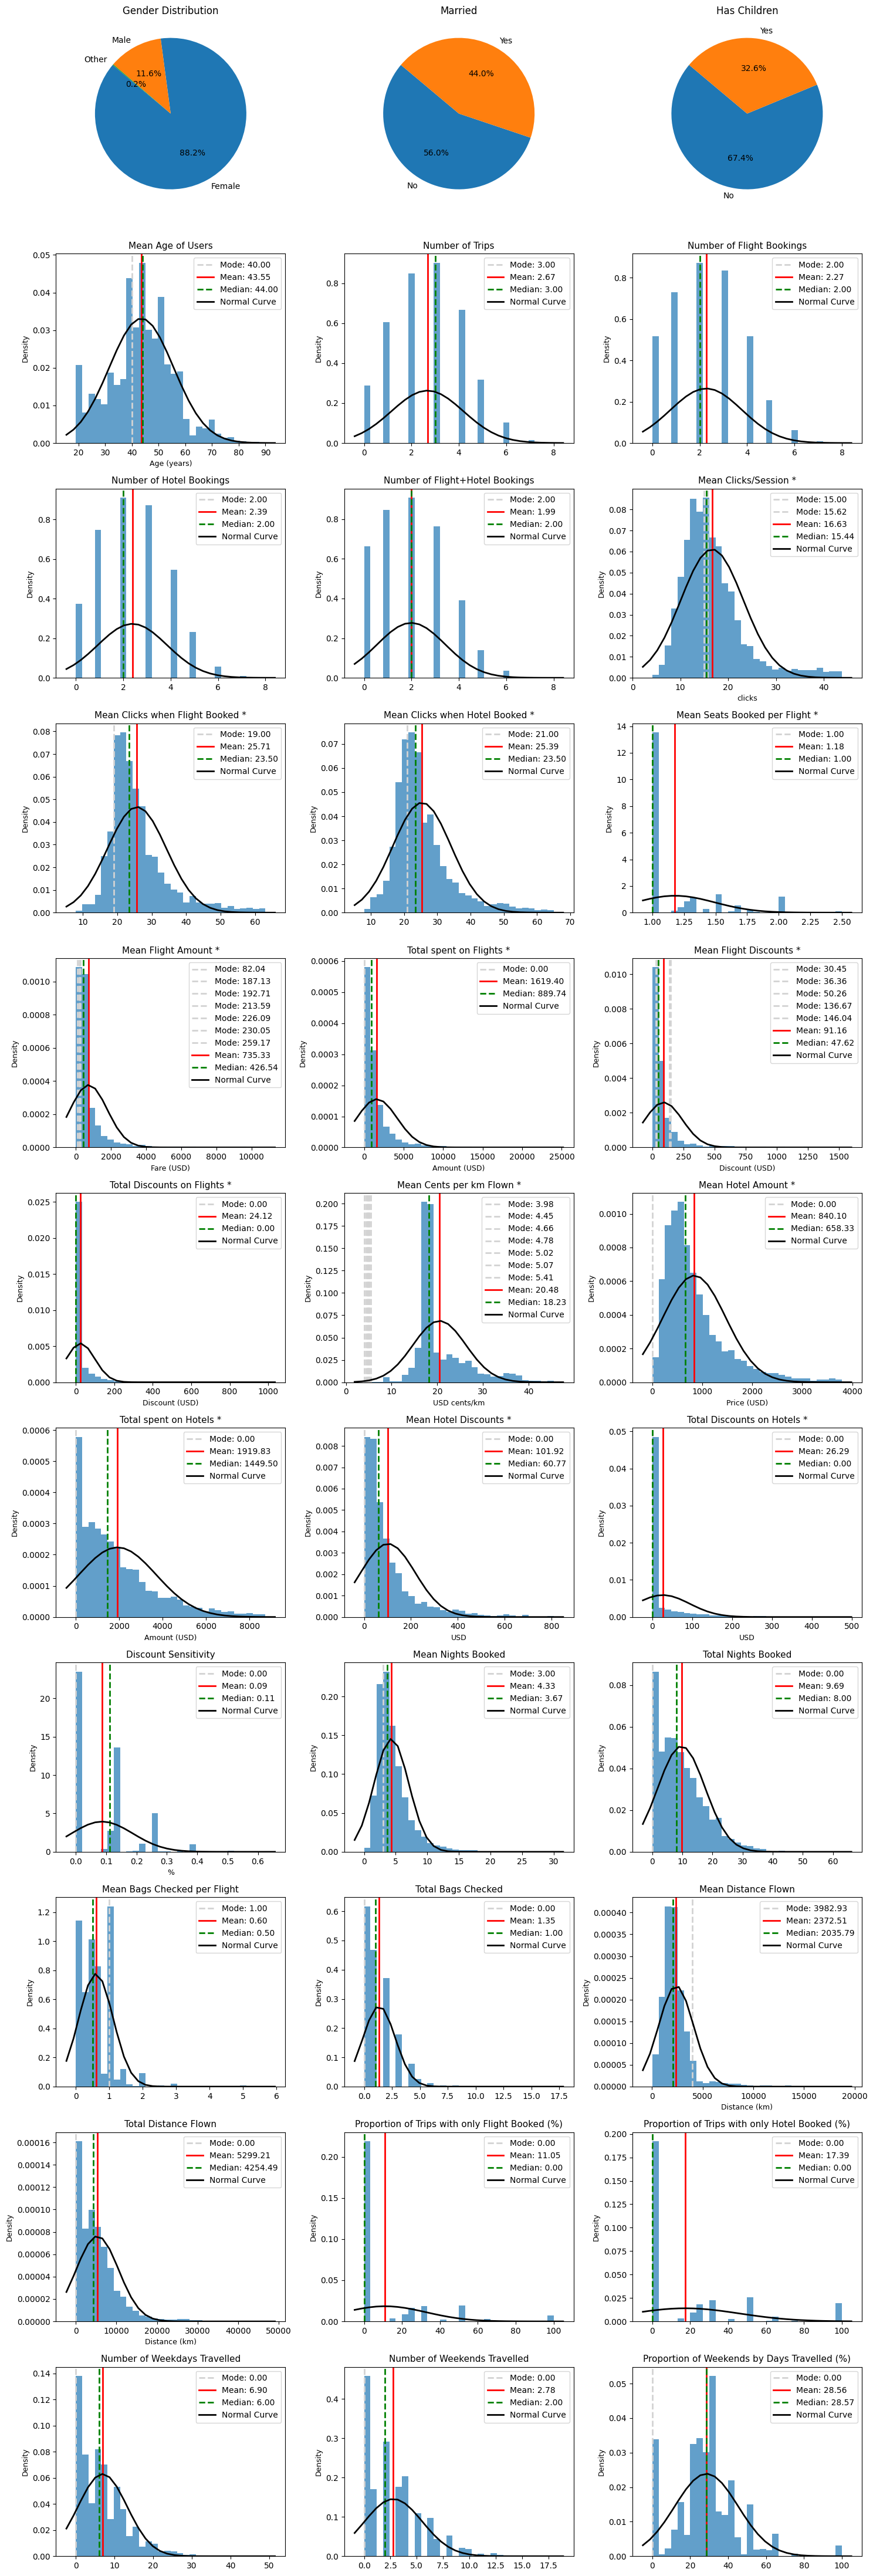

In [10]:
ctm = config.central_tendency_measure.title()
user_plots = {
  'gender': FrequencyPie(users.gender, 'Gender Distribution', {'F': 'Female', 'M': 'Male', 'O': 'Other'}),
  'married': FrequencyPie(users.married.astype(int), 'Married', {False: 'No', True: 'Yes'}),
  'has_children': FrequencyPie(users.has_children.astype(int), 'Has Children', {False: 'No', True: 'Yes'}),
  'age': Histogram(users.age, f'{ctm} Age of Users', 'Age (years)'),
  'total_trips': Histogram(users.total_trips, 'Number of Trips'),
  'flight_bookings': Histogram(users.flight_bookings, 'Number of Flight Bookings'),
  'hotel_bookings': Histogram(users.hotel_bookings, 'Number of Hotel Bookings'),
  'combo_bookings': Histogram(users.combo_bookings, 'Number of Flight+Hotel Bookings'),
  'avg_page_clicks': Histogram(clip_outliers(users.avg_page_clicks), f'{ctm} Clicks/Session *', 'clicks'),
  'avg_page_clicks_flight_booked': Histogram(clip_outliers(users.avg_page_clicks_flight_booked), f'{ctm} Clicks when Flight Booked *'),
  'avg_page_clicks_hotel_booked': Histogram(clip_outliers(users.avg_page_clicks_hotel_booked), f'{ctm} Clicks when Hotel Booked *'),
  'avg_seats_booked': Histogram(clip_outliers(users.avg_seats_booked), f'{ctm} Seats Booked per Flight *'),
  'avg_flight_amount': Histogram(clip_outliers(users.avg_flight_amount), f'{ctm} Flight Amount *', 'Fare (USD)'),
  'total_flight_amount': Histogram(clip_outliers(users.total_flight_amount), 'Total spent on Flights *', 'Amount (USD)'),
  'avg_flight_discount': Histogram(clip_outliers(users.avg_flight_discount), f'{ctm} Flight Discounts *', 'Discount (USD)'),
  'total_flight_discount': Histogram(clip_outliers(users.total_flight_discount), 'Total Discounts on Flights *', 'Discount (USD)'),
  'avg_cents_km_flown': Histogram(clip_outliers(users.avg_cents_km_flown), f'{ctm} Cents per km Flown *', 'USD cents/km'),
  'avg_hotel_amount': Histogram(clip_outliers(users.avg_hotel_amount), f'{ctm} Hotel Amount *', 'Price (USD)'),
  'total_hotel_amount': Histogram(clip_outliers(users.total_hotel_amount), 'Total spent on Hotels *', 'Amount (USD)'),
  'avg_hotel_discount': Histogram(clip_outliers(users.avg_hotel_discount), f'{ctm} Hotel Discounts *', 'USD'),
  'total_hotel_discount': Histogram(clip_outliers(users.total_hotel_discount), 'Total Discounts on Hotels *', 'USD'),
  'discount_sensitivity': Histogram(users.discount_sensitivity, 'Discount Sensitivity', '%'),
  'avg_hotel_nights': Histogram(users.avg_hotel_nights, f'{ctm} Nights Booked'),
  'total_hotel_nights': Histogram(users.total_hotel_nights, 'Total Nights Booked'),
  'avg_checked_bags': Histogram(users.avg_checked_bags, f'{ctm} Bags Checked per Flight'),
  'total_checked_bags': Histogram(users.total_checked_bags, 'Total Bags Checked'),
  'avg_distance_flown': Histogram(users.avg_distance_flown, f'{ctm} Distance Flown', 'Distance (km)'),
  'total_distance_flown': Histogram(users.total_distance_flown, 'Total Distance Flown', 'Distance (km)'),
  'pct_only_flight_booked': Histogram(100*users.pct_only_flight_booked, 'Proportion of Trips with only Flight Booked (%)'),
  'pct_only_hotel_booked': Histogram(100*users.pct_only_hotel_booked, 'Proportion of Trips with only Hotel Booked (%)'),
  'weekdays_travelled': Histogram(users.weekdays_travelled, 'Number of Weekdays Travelled'),
  'weekends_travelled': Histogram(users.weekends_travelled, 'Number of Weekends Travelled'),
  'weekends_proportion': Histogram(100*users.weekends_proportion, 'Proportion of Weekends by Days Travelled (%)'),
}

print("* = with outliers clipped above 3 standard deviations from the mean")
PlotGrid(n_cols=3).plot_all(user_plots.values())

### Sessions

* = with outliers clipped above 3 standard deviations from the mean


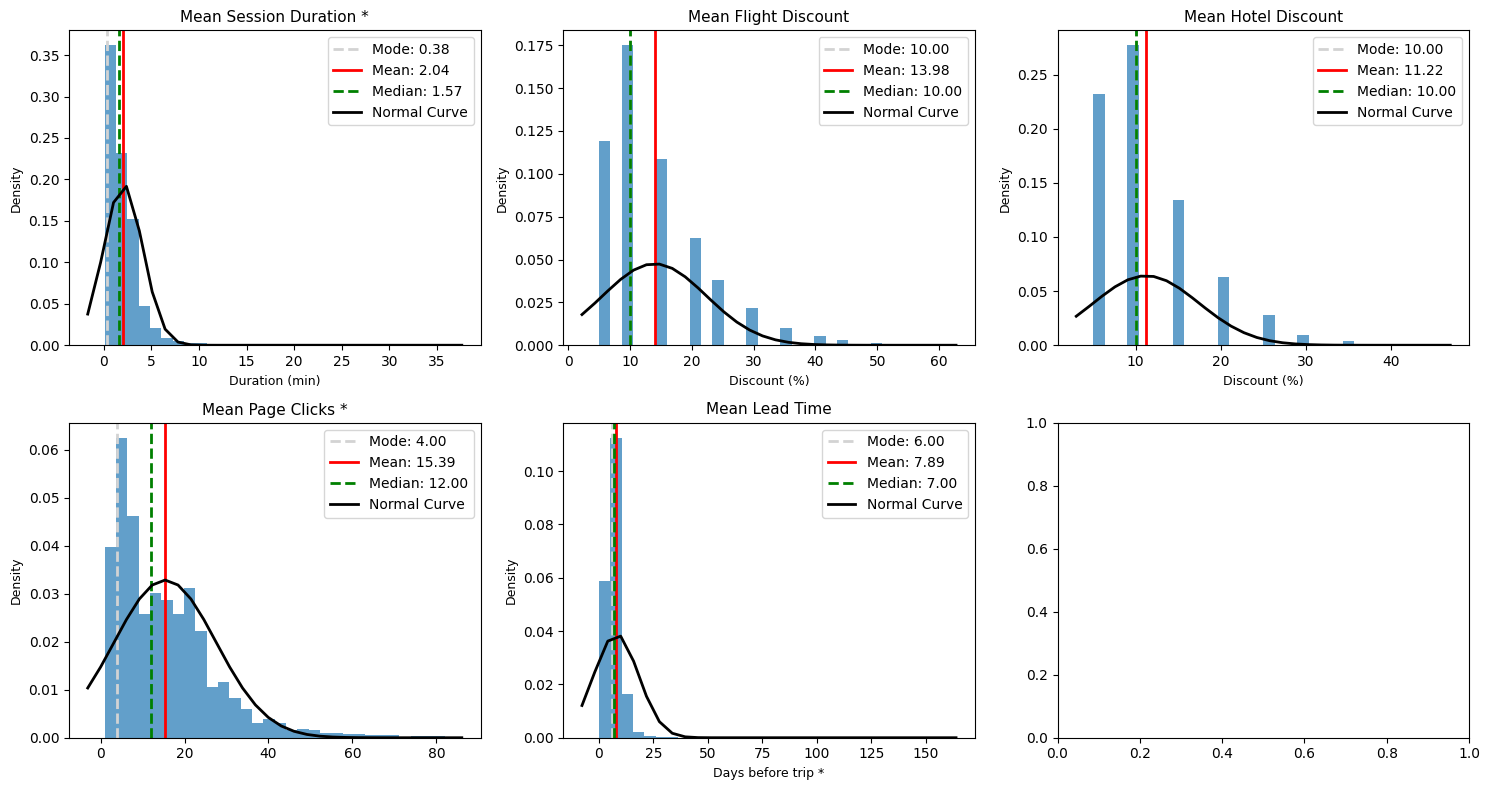

In [11]:
session_plots = {
  'session_duration': Histogram(clip_outliers(sessions.session_duration), f'{ctm} Session Duration *', 'Duration (min)'),
  'flight_discount_amount': Histogram(100*sessions.flight_discount_amount, f'{ctm} Flight Discount', 'Discount (%)'),
  'hotel_discount_amount': Histogram(100*sessions.hotel_discount_amount, f'{ctm} Hotel Discount', 'Discount (%)'),
  'page_clicks': Histogram(clip_outliers(sessions.page_clicks), f'{ctm} Page Clicks *'),
  'lead_time': Histogram(clip_outliers(sessions.lead_time), f'{ctm} Lead Time', 'Days before trip *'),
}

print("* = with outliers clipped above 3 standard deviations from the mean")
PlotGrid(n_cols=3).plot_all(session_plots.values())

### Hotels

* = with outliers clipped above 3 standard deviations from the mean


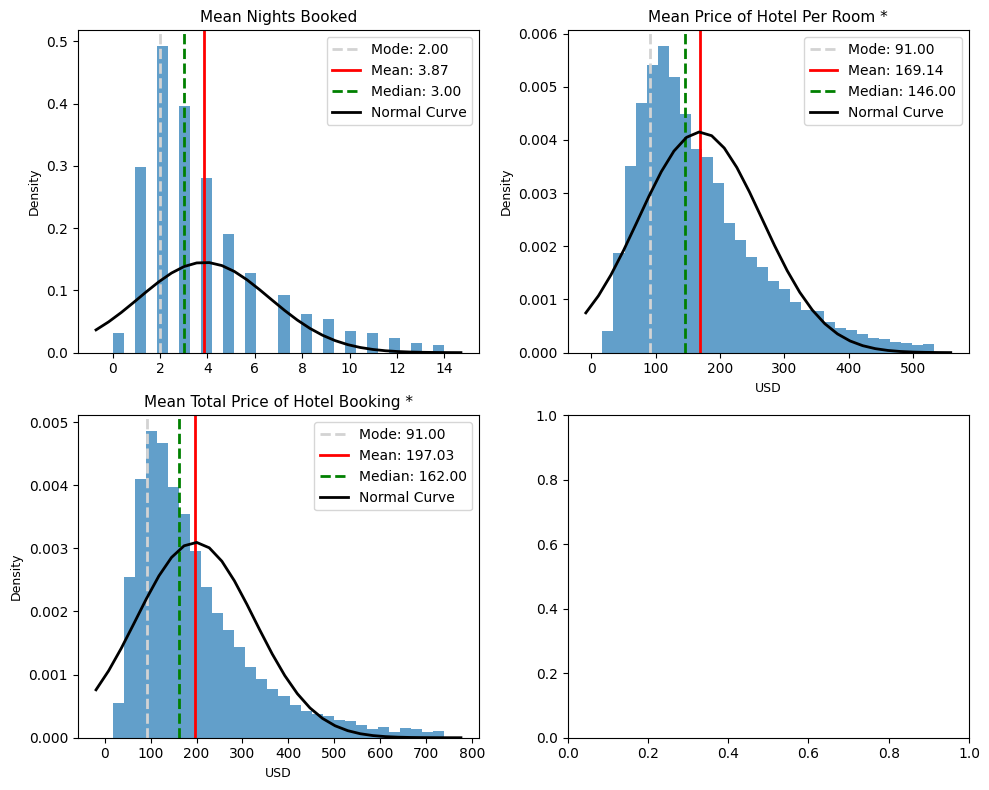

In [12]:
hotel_plots = {
    'nights': Histogram(clip_outliers(hotels.nights), f'{ctm} Nights Booked'),
    'hotel_per_room_usd': Histogram(clip_outliers(hotels.hotel_per_room_usd), f'{ctm} Price of Hotel Per Room *', 'USD'),
    'total_hotel_price': Histogram(clip_outliers(hotels.total_hotel_price), f'{ctm} Total Price of Hotel Booking *', 'USD'),
}

print("* = with outliers clipped above 3 standard deviations from the mean")
PlotGrid(n_cols=2).plot_all(hotel_plots.values())

### Flights

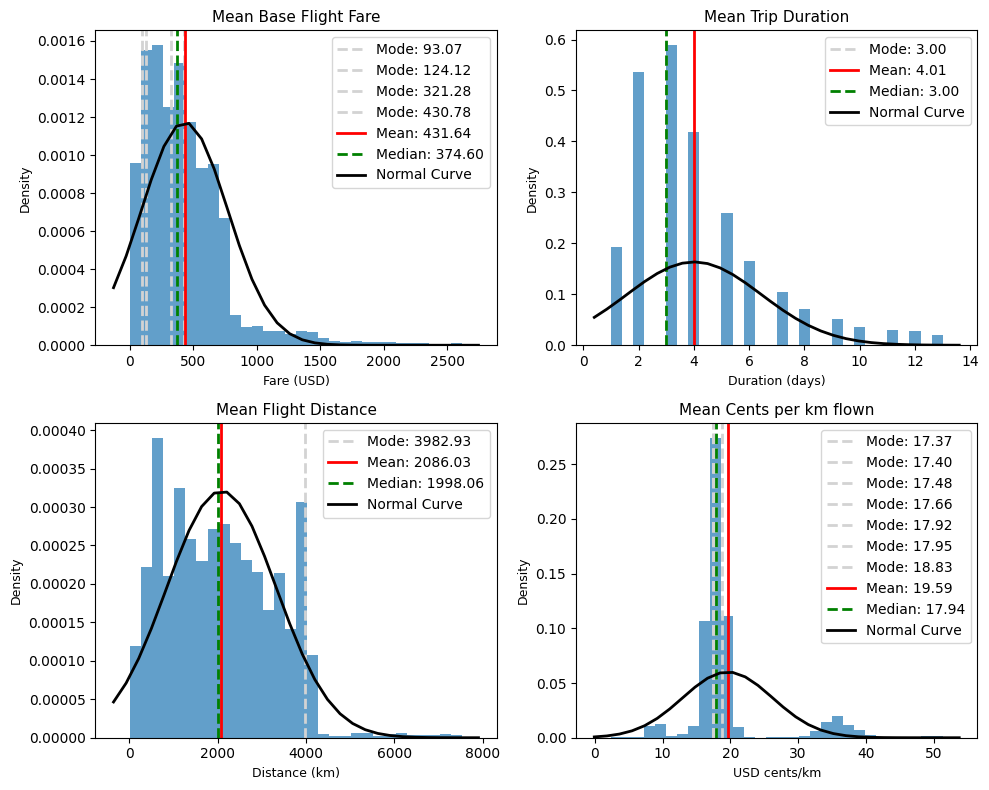

In [13]:
flight_plots = {
    'base_fare_usd': Histogram(clip_outliers(flights.base_fare_usd), f'{ctm} Base Flight Fare', 'Fare (USD)'),
    'trip_duration': Histogram(clip_outliers(flights.trip_duration), f'{ctm} Trip Duration', 'Duration (days)'),
    'flight_distance_km': Histogram(clip_outliers(flights.flight_distance_km), f'{ctm} Flight Distance', 'Distance (km)'),
    'cents_per_km_flown': Histogram(clip_outliers(flights.cents_per_km_flown), f'{ctm} Cents per km flown', 'USD cents/km'),
}

PlotGrid(n_cols=2).plot_all(flight_plots.values())

> `base_fare_usd` have a very right-skewed distribuition, while in `cents_per_km_flown` has clearly 4 distruitions: under 10, between 10 and 25, between 30 and 45 and above 45.

## Correlation Analysis of Numerical Features

Let's investigate the correlation between various numerical features to understand their relationships. A heatmap can visually represent these correlations.

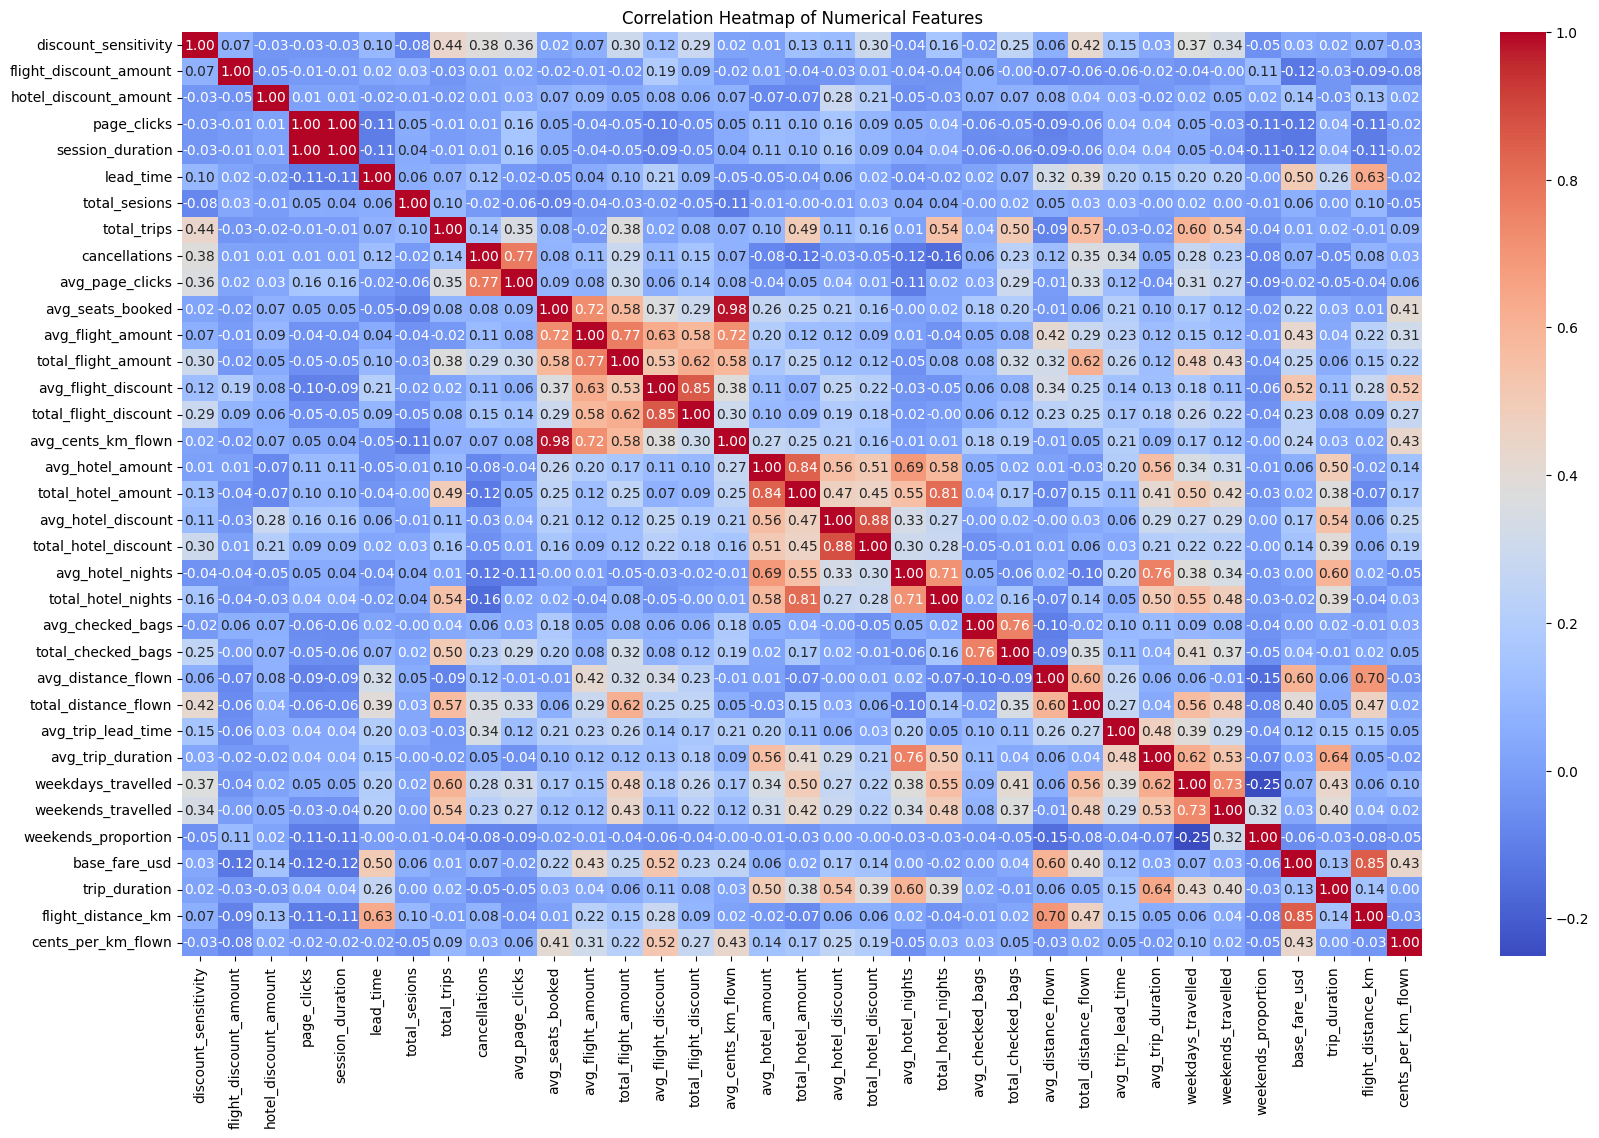

In [14]:
# Select relevant numerical columns from df_merged for correlation analysis
correlation_columns = [
'discount_sensitivity',
   'flight_discount_amount',
   'hotel_discount_amount',
   'page_clicks',
   'session_duration',
   'lead_time',
   'total_sesions',
   'total_trips',
   'cancellations',
   'avg_page_clicks',
   'avg_seats_booked',
   'avg_flight_amount',
   'total_flight_amount',
   'avg_flight_discount',
   'total_flight_discount',
   'avg_cents_km_flown',
   'avg_hotel_amount',
   'total_hotel_amount',
   'avg_hotel_discount',
   'total_hotel_discount',
   'avg_hotel_nights',
   'total_hotel_nights',
   'avg_checked_bags',
   'total_checked_bags',
   'avg_distance_flown',
   'total_distance_flown',
   'avg_trip_lead_time',
   'avg_trip_duration',
   'weekdays_travelled',
   'weekends_travelled',
   'weekends_proportion',
   'base_fare_usd',
   'trip_duration',
   'flight_distance_km',
   'cents_per_km_flown',
]

CorrelationHeatmap(
    df = df_merged, 
    columns = correlation_columns, 
    title = 'Correlation Heatmap of Numerical Features'
).plot()

* `session_duration` and `page_clicks` are perfectly correlated, show the rate of page clicks is constant.
* There's a strong correlation between `flight_distance_km` and `base_fare_usd`, which makes sense, as longer flights are expected to cost more.
* There's a mild correlation between `lead_time` and `flight_distance_km`, suggesting that users tend to book longer flights in advance.
* There's a mild correlation between `base_fare_usd` and `lead_time`, showing that early planners tend to pay more than last-minute bookings.

The other strong correlations are results of a clear relationship between features, like the averages and totals of discounts and amounts, and, for instance, the hotel amount and number of nights, or flight amount and number of seats.

## Conversion Analysis
What drives users to actually "pull the trigger"?

### The "Discount Hook"
* Do discounts increase booking rate?
* Is there a "magic number" where conversion rates spike significantly?

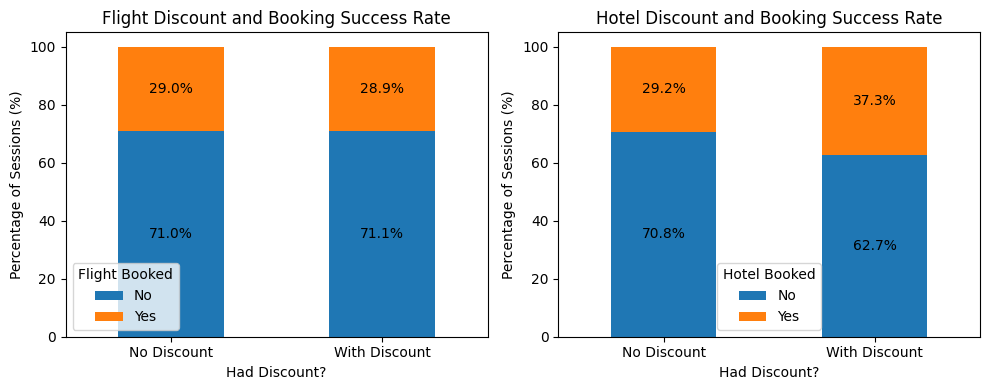

In [15]:
discount_plots = [CrossTabBar(
    x_data = sessions[f'{booking}_discount'], 
    y_data = sessions[f'{booking}_booked'], 
    title = f'{booking.capitalize()} Discount and Booking Success Rate',
    x_label = 'Had Discount?',
    y_label = 'Percentage of Sessions (%)',
    x_value_labels = {False: 'No Discount', True: 'With Discount'},
    y_value_labels = {False: 'No', True: 'Yes'},
    legend_title = f'{booking.capitalize()} Booked'
) for booking in ['flight', 'hotel']]

PlotGrid(n_cols=2).plot_all(discount_plots)

> We can observe that discounts are taken sensibly more for Hotel bookings but than for Flights

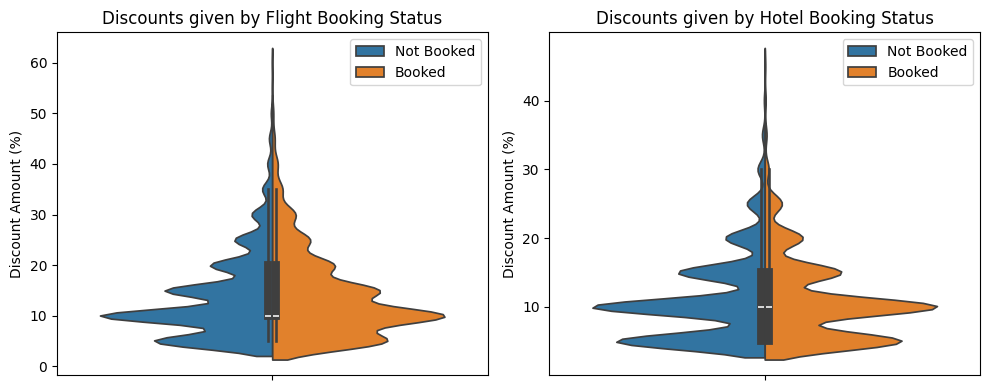

In [16]:
PlotGrid(n_cols=2).plot_all([
    SplitViolin(
        y_data = 100*sessions.flight_discount_amount, 
        split_data = sessions.flight_booked, 
        title = 'Discounts given by Flight Booking Status',
        y_label = 'Discount Amount (%)',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    ),
    SplitViolin(
        y_data = 100*sessions.hotel_discount_amount, 
        split_data = sessions.hotel_booked, 
        title = 'Discounts given by Hotel Booking Status',
        y_label = 'Discount Amount (%)',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    )
])

> We observe no significant difference in discount distribuition for booked and not booked flights and hotels.
> We can conclude that there is no specific discount amount that makes bookings more likely

### Friction vs. Engagement
* Does a high number of clicks indicate high intent, or does it suggest the user is frustrated and can't find what they want?

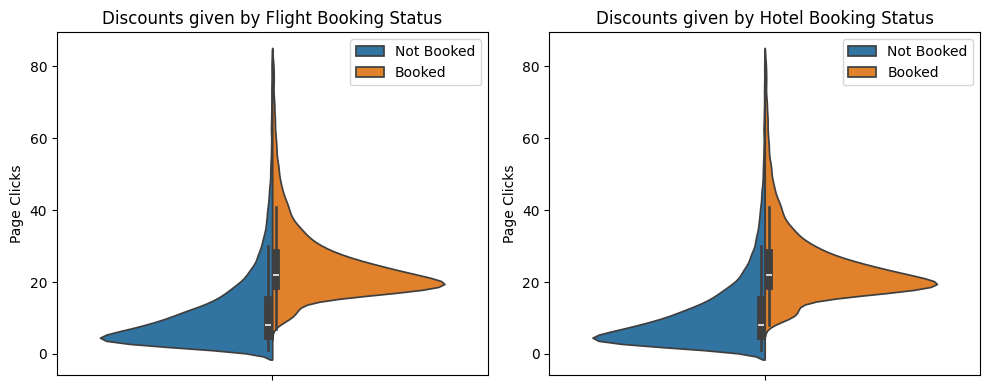

In [17]:
PlotGrid(n_cols=2).plot_all([
    SplitViolin(
        y_data = clip_outliers(sessions.page_clicks), 
        split_data = sessions.flight_booked, 
        title = 'Discounts given by Flight Booking Status',
        y_label = 'Page Clicks',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    ),
    SplitViolin(
        y_data = clip_outliers(sessions.page_clicks),
        split_data = sessions.hotel_booked, 
        title = 'Discounts given by Hotel Booking Status',
        y_label = 'Page Clicks',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    )
])

> We can see that sessions with booking have around 15 clicks more than sessions without, both for hotels and flights.

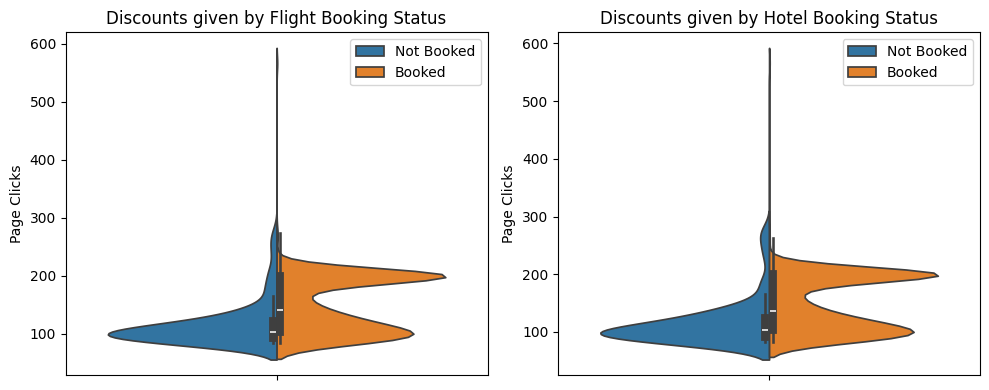

In [18]:
# Funny anomally
# Clipping everything but the outliers...
df_clipped = sessions[
    (sessions['page_clicks'] - sessions['page_clicks'].mean()).abs()
    > 3 * sessions['page_clicks'].std()
]

PlotGrid(n_cols=2).plot_all([
    SplitViolin(
        y_data = df_clipped.page_clicks, 
        split_data = df_clipped.flight_booked, 
        title = 'Discounts given by Flight Booking Status',
        y_label = 'Page Clicks',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    ),
    SplitViolin(
        y_data = df_clipped.page_clicks,
        split_data = df_clipped.hotel_booked, 
        title = 'Discounts given by Hotel Booking Status',
        y_label = 'Page Clicks',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    )
])

> We observe a spike around 200 clicks, that might need some further investigation. It can be, for example, users ta look and look, try different dates or add-ons, but in the end they book it.

### The Multi-Product Lift
* Are users who book a flight more likely to book a hotel in the same trip_id?

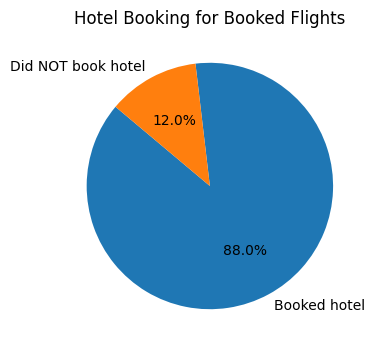

In [19]:
df_flights_booked = sessions[sessions.flight_booked]
FrequencyPie(
    data = df_flights_booked.hotel_booked, 
    title = 'Hotel Booking for Booked Flights',
    labels = {True:'Booked hotel', False:'Did NOT book hotel'}
).plot()

> The vast majority of users that book a flight also book a hotel, thefore offering a combo might be interesting to most customers

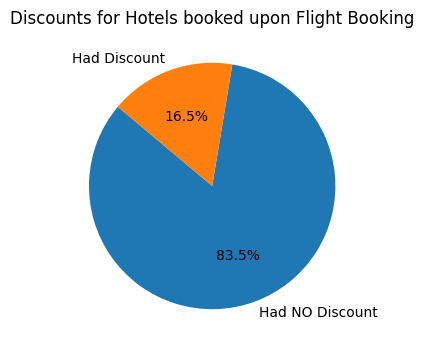

In [20]:
df_flights_booked_with_hotel = sessions[sessions.flight_booked & sessions.hotel_booked]
FrequencyPie(
    data = df_flights_booked_with_hotel.hotel_discount, 
    title = 'Discounts for Hotels booked upon Flight Booking',
    labels = {True: 'Had Discount', False: 'Had NO Discount'}
).plot()

> So, when booking flights, most customers also book hotels, even when no discount is offered for the hotel booking

## Pricing and Cancellation Patterns

### Cancelation Profile
* Do discounts influence the cancellation rate?
* Are certain `trip_airline` carriers or `hotel_name` chains associated with higher cancellation rates? Is it a user trait or a service provider issue?

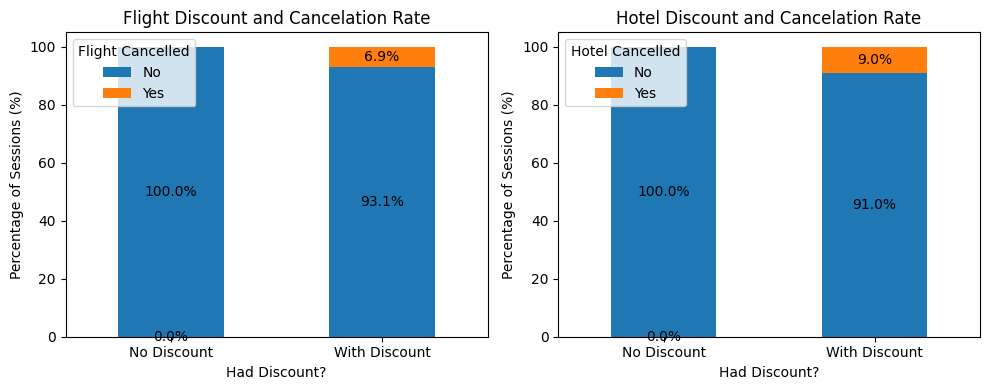

In [21]:
discount_plots = [
    CrossTabBar(
        x_data = sessions[f'{booking}_discount'], 
        y_data = sessions['cancellation'], 
        title = f'{booking.capitalize()} Discount and Cancelation Rate',
        x_label = 'Had Discount?',
        y_label = 'Percentage of Sessions (%)',
        x_value_labels = {False: 'No Discount', True: 'With Discount'},
        y_value_labels = {False: 'No', True: 'Yes'},
        legend_title = f'{booking.capitalize()} Cancelled'
    ) 
    for booking in ['flight', 'hotel']
]

PlotGrid(n_cols=2).plot_all(discount_plots)

> Strangly, it seems discounts have worse results than no discounts, when it comes to cancellation rate

#### Airlines
Airlines with cancellation rate above 50%

In [22]:
airline_stats = df_merged.groupby('trip_airline').agg(
    total_bookings=('flight_booked', 'sum'),
    total_cancellations=('cancellation', 'sum')
).reset_index()

airline_stats['cancellation_rate'] = (
    airline_stats['total_cancellations'] / airline_stats['total_bookings'] * 100
).round(2)

airline_stats[airline_stats.cancellation_rate > 50].sort_values(by='cancellation_rate', ascending=False)

,trip_airline,total_bookings,total_cancellations,cancellation_rate
22,Air Serbia,1,1,100.00
135,Shanghai Airlines,1,1,100.00
146,SunExpress,3,2,66.67


> We can see many airlines with high cancellation rates, especially "Air Serbia", "Shanghai Airlines" and "SunExpress"

#### Hotels
Hotels with cancellation rate above 50%

In [23]:
hotel_stats = df_merged.groupby('hotel_name').agg(
    total_bookings=('hotel_booked', 'sum'),
    total_cancellations=('cancellation', 'sum')
).reset_index()

# 3. Calculate a Cancellation Rate for better context
hotel_stats['cancellation_rate'] = (
    hotel_stats['total_cancellations'] / hotel_stats['total_bookings'] * 100
).round(2)

hotel_stats[hotel_stats.cancellation_rate > 50].sort_values(by='cancellation_rate', ascending=False)

,hotel_name,total_bookings,total_cancellations,cancellation_rate
291,Crowne Plaza - antalya,1,1,100.0


> We observe many hotels with high cancelation rates, especially "Crowne Plaza - antalya"

### Lead Time Analysis
* Do "last-minute" bookers pay significantly more `base_fare_usd`, and do they use more discounts?
* Do discounts affect cancellation rate?

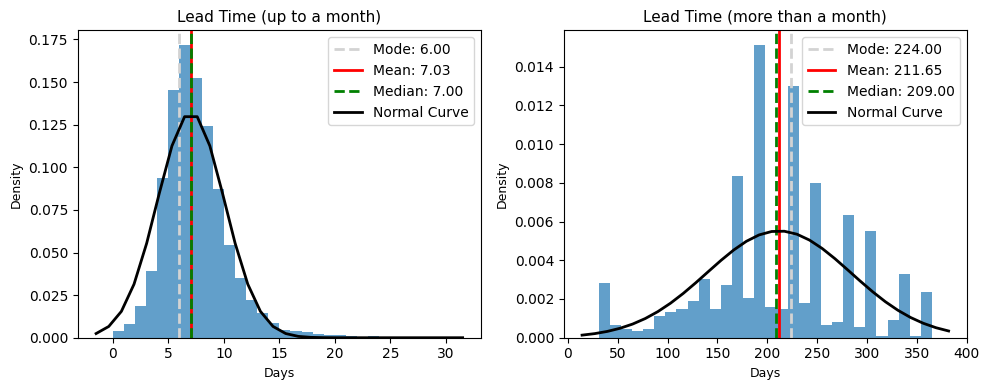

In [24]:
df_short_planners = df_merged[df_merged.lead_time <= 30]
df_long_planners = df_merged[df_merged.lead_time > 30]

PlotGrid(n_cols=2).plot_all([
    Histogram(df_short_planners.lead_time, 'Lead Time (up to a month)', 'Days'),
    Histogram(df_long_planners.lead_time, 'Lead Time (more than a month)', 'Days')
])

> We can see there are two separate distribuitions for lead time: one between 0 and 20 days before trip, and another between 50 and 400 days.

In [25]:
def plot_leadtime_scatter(column, y_label, unit):
  PlotGrid(n_cols=2, cell_size=(6, 4)).plot_all([
      ScatterPlot(
        x = df_short_planners.lead_time, y = df_short_planners[column], 
        title = y_label + ' for bookings up to a month in advance',
        x_label = 'Lead Time', y_label = y_label,
        x_unit = 'days', y_unit = unit
      ),
      ScatterPlot(
        x = df_long_planners.lead_time, y = df_long_planners[column],
        title = y_label + ' for bookings longer than a month in advance',
        x_label = 'Lead Time', y_label = y_label,
        x_unit = 'days', y_unit = unit
      )
  ])

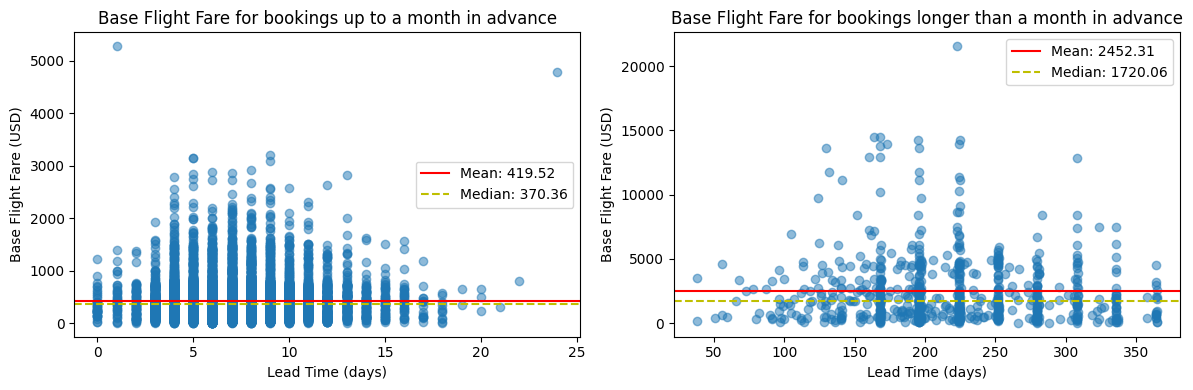

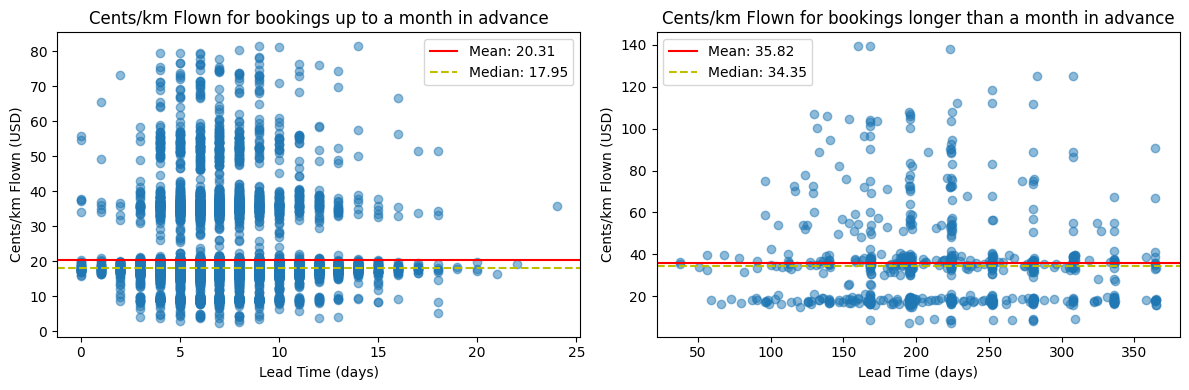

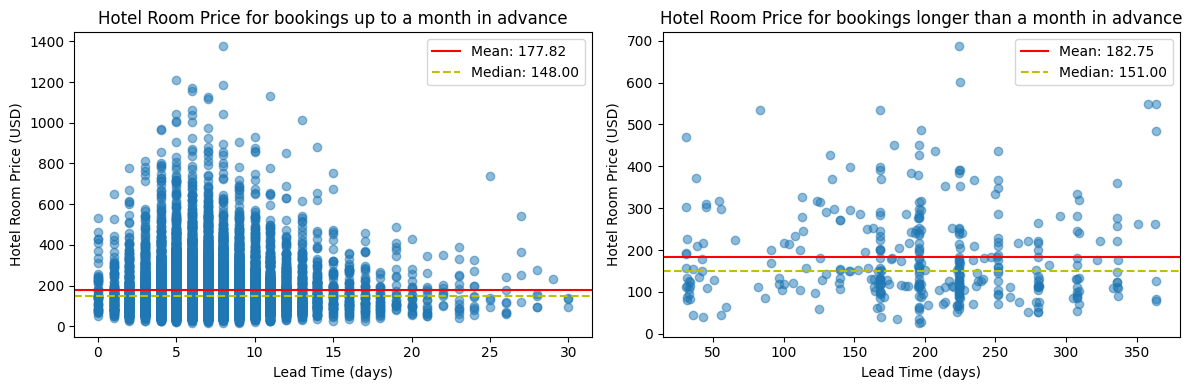

In [26]:
plot_leadtime_scatter('base_fare_usd', 'Base Flight Fare', 'USD')
plot_leadtime_scatter('cents_per_km_flown', 'Cents/km Flown', 'USD')
plot_leadtime_scatter('hotel_per_room_usd', 'Hotel Room Price', 'USD')

> Early planners pay significantly more for flights and a bit more for hotels

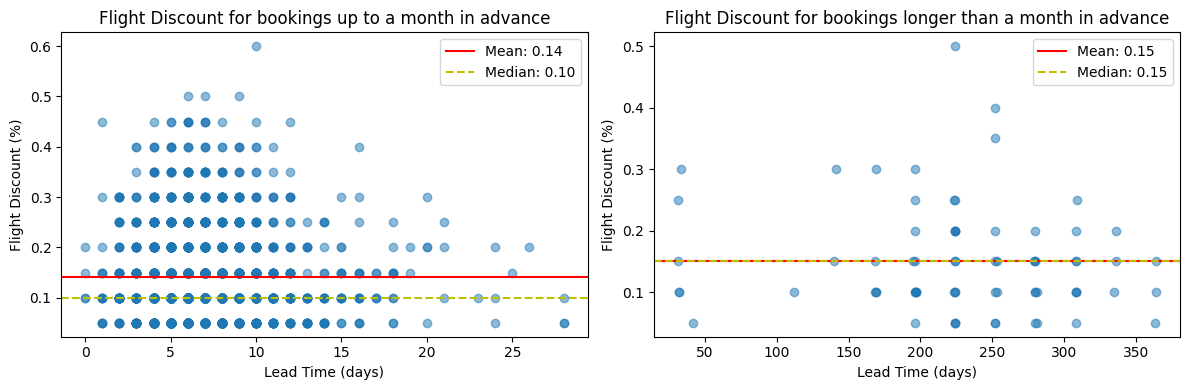

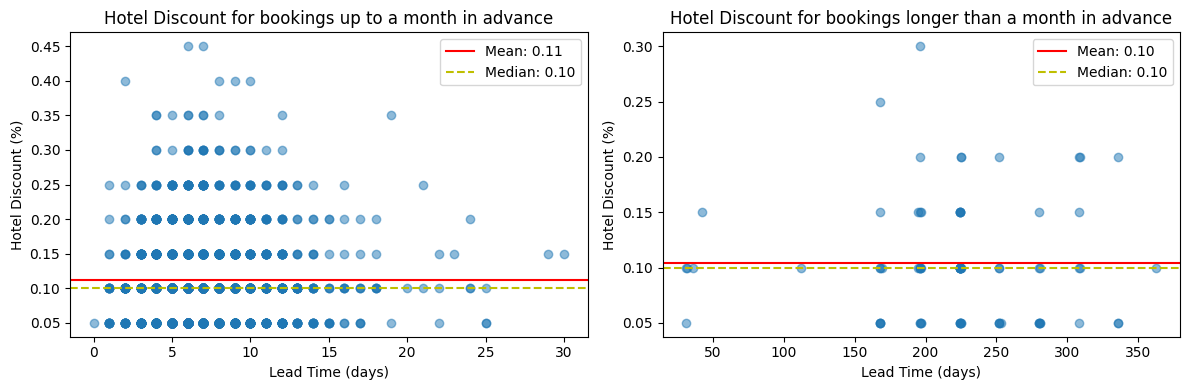

In [27]:
plot_leadtime_scatter('flight_discount_amount', 'Flight Discount', '%')
plot_leadtime_scatter('hotel_discount_amount', 'Hotel Discount', '%')

> We don't see a significant difference between discounts taken in early and last-minute bookings

## Time Series Trends: Bookings and Cancellations

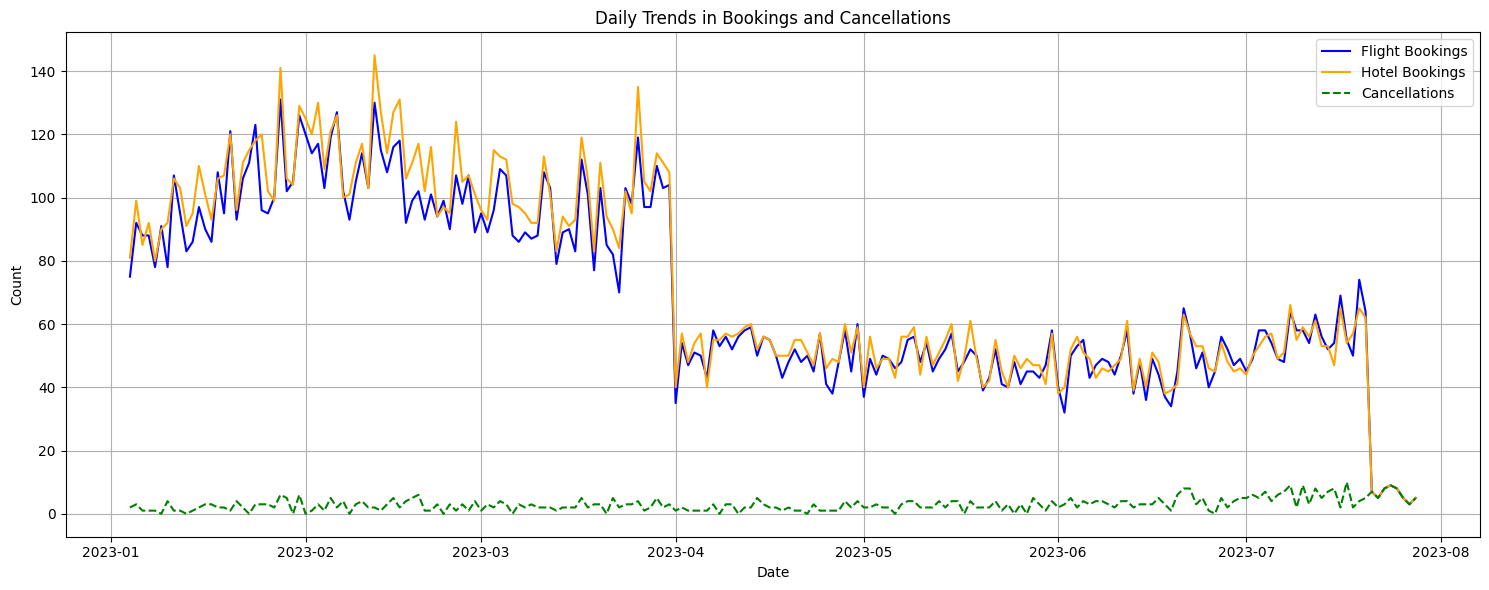

In [ ]:
sessions['session_date'] = sessions['session_start'].dt.date
daily_bookings = sessions.groupby('session_date').agg(
    total_flight_bookings=('flight_booked', 'sum'),
    total_hotel_bookings=('hotel_booked', 'sum'),
    total_cancellations=('cancellation', 'sum')
).reset_index()

TimeSeriesPlot(
    title='Daily Trends in Bookings and Cancellations',
    date_column='session_date',
    lines=[
        TimeSeriesPlot.Line('total_flight_bookings', 'Flight Bookings', color='blue'),
        TimeSeriesPlot.Line('total_hotel_bookings', 'Hotel Bookings', color='orange'),
        TimeSeriesPlot.Line('total_cancellations', 'Cancellations', color='green', linestyle='--'),
    ],
    df=daily_bookings,
).plot()

> Here we see a signficant drop in bookigs by the begining of April and by the end of July